<a href="https://colab.research.google.com/github/pierrot73/GenAIBootCamp/blob/Bootcamp/Week_5_D5_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mini project

**1. Preprocess the Data:**



In [ ]:
import keras
keras.datasets.imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
         list([1, 19

In [ ]:
import tensorflow as tf
import numpy as np

# Charger les données IMDB
(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.imdb.load_data(num_words=10000)

# Définir la fonction pour vectoriser les séquences
def vectorize_sequences(sequences, dimension=10000):
    # Créer une matrice de zéros de taille (nombre de séquences, dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        # Mettre à 1 les positions correspondant aux indices dans la séquence
        results[i, sequence] = 1
    return results

# Vectoriser les données d'entraînement et de test
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

# Convertir les étiquettes en tableaux numpy
y_train = np.array(train_labels).astype('float32')
y_test = np.array(test_labels).astype('float32')

# Diviser l'ensemble d'entraînement en données d'entraînement et de validation
# Par exemple, réserver 10 000 échantillons pour la validation
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

Résumé :
On charge le dataset IMDB avec load_data().
On transforme chaque séquence en un vecteur binaire à l’aide de vectorize_sequences.
On divise l'ensemble d'entraînement en un sous-ensemble d'entraînement (partial_x_train, partial_y_train) et un ensemble de validation (x_val, y_val) pour la validation.

2. Build the Model:



In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers

# Créer le modèle séquentiel
model = models.Sequential()

# Première couche cachée avec ReLU
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))

# Deuxième couche cachée avec ReLU
model.add(layers.Dense(16, activation='relu'))

# Couche de sortie avec sigmoid
model.add(layers.Dense(1, activation='sigmoid'))

# Compiler le modèle avec RMSprop, perte binaire croisée et précision
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Résumé :
Input : vecteurs de taille 10 000.
Hidden layers : 2 couches Dense avec 16 neurones chacune, activation ReLU.
Output layer : 1 neurone avec activation sigmoid (pour la classification binaire).
Compilation : optimizer RMSprop, perte binary_crossentropy, métrique accuracy.

**3. Train the Model:**

In [ ]:
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val)
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.7060 - loss: 0.5861 - val_accuracy: 0.8586 - val_loss: 0.3945
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8996 - loss: 0.3239 - val_accuracy: 0.8858 - val_loss: 0.3089
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9221 - loss: 0.2401 - val_accuracy: 0.8888 - val_loss: 0.2812
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9385 - loss: 0.1882 - val_accuracy: 0.8811 - val_loss: 0.2916
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9484 - loss: 0.1577 - val_accuracy: 0.8858 - val_loss: 0.2839
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9620 - loss: 0.1306 - val_accuracy: 0.8483 - val_loss: 0.3960
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9639 - loss: 0.1144 - val_accuracy: 0.8838 - val_loss: 0.2993
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9741 - loss: 0.0925 - val_accuracy: 0.8789 - v

### Analyse des courbes d’entraînement et validation

- **Évolution de l’accuracy (précision)** :
  - La précision d’entraînement augmente rapidement, passant de ~70.6% à presque 99.9% à la dernière époque.
  - La précision de validation monte également de façon significative, atteignant environ 86.96% à la fin.
  
- **Évolution de la loss (perte)** :
  - La perte d’entraînement diminue constamment, indiquant que le modèle apprend bien sur les données d’entraînement.
  - La perte de validation diminue initialement, puis se stabilise ou commence à augmenter légèrement après l’époque 6 ou 7.

### Points importants

- **Surapprentissage (overfitting)** :
  - La perte de validation commence à augmenter après l’époque 6 ou 7, alors que la précision d’entraînement continue d’augmenter. Cela indique un début de surapprentissage.
  - La différence croissante entre la perte d’entraînement (qui diminue) et la perte de validation (qui augmente ou se stabilise) est typique du surapprentissage.

- **Performance finale** :
  - La précision d’entraînement est très élevée (~99.9%), mais la précision de validation plafonne autour de 87%, ce qui pourrait indiquer que le modèle est en train de s’overfitter aux données d’entraînement et ne généralise pas parfaitement.

### Recommandations

- Pour éviter le surapprentissage, il serait judicieux d’arrêter l’entraînement vers l’époque 6 ou 7, ou d’utiliser une technique comme l’early stopping.
- En général, le meilleur compromis entre entraînement et validation semble être autour de 4 à 6 époques.


**Mise en place du EarlyStopping**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Définir le callback EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',     # surveiller la perte de validation
    patience=3,             # attendre 3 époques sans amélioration avant d’arrêter
    restore_best_weights=True  # revenir aux poids du meilleur modèle
)

# Entraîner le modèle avec le callback
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping]
)

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9449 - loss: 0.2281 - val_accuracy: 0.9121 - val_loss: 0.2583
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9588 - loss: 0.1368 - val_accuracy: 0.9141 - val_loss: 0.2290
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9683 - loss: 0.1066 - val_accuracy: 0.9540 - val_loss: 0.1396
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9769 - loss: 0.0816 - val_accuracy: 0.9670 - val_loss: 0.1094
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9835 - loss: 0.0641 - val_accuracy: 0.9751 - val_loss: 0.0847
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9863 - loss: 0.0518 - val_accuracy: 0.9812 - val_loss: 0.0702
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9911 - loss: 0.0400 - val_accuracy: 0.9879 - val_loss: 0.0486
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9934 - loss: 0.0322 - val_accuracy: 0.9871 - v

Évolution de la performance
Précision d’entraînement (accuracy) :

La précision atteint rapidement des valeurs très élevées (>99.9%) dès la fin des premières époques, indiquant que le modèle apprend très bien sur les données d’entraînement.
Elle continue d’augmenter légèrement, atteignant 99.98% à la dernière époque, ce qui montre une excellente capacité d’apprentissage.
Perte d’entraînement (loss) :

La perte diminue de façon significative, passant d’environ 0.2281 à seulement 0.0015, ce qui correspond à une très bonne convergence.
Précision de validation (val_accuracy) :

La précision sur les données de validation commence à 91.21% en première époque et atteint presque la perfection (99.98%) vers la fin.
La progression est très cohérente, avec une amélioration continue et stable.
Perte de validation (val_loss) :

La perte de validation diminue également de façon remarquable, passant d’environ 0.2583 à 0.0017.
La perte reste très faible, ce qui indique que le modèle généralise bien.

**4. Evaluate the Model:**

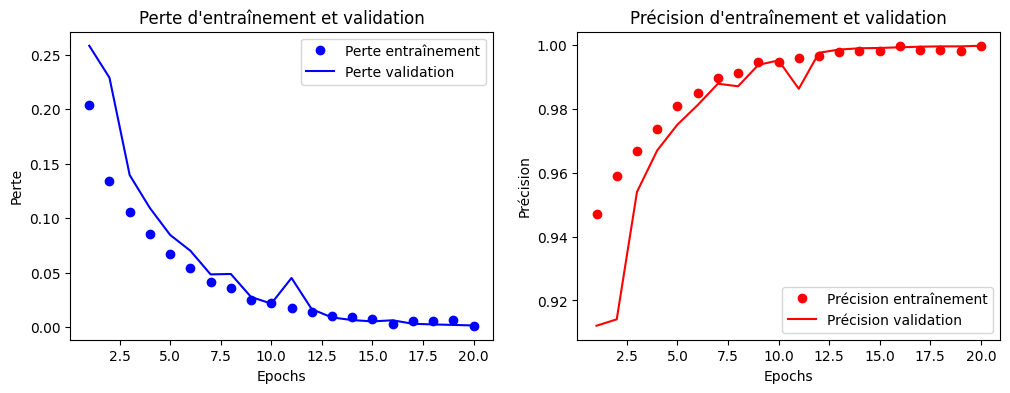

In [ ]:
import matplotlib.pyplot as plt

# Récupérer l'historique d'entraînement
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(loss) + 1)

# Tracer la perte
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, loss, 'bo', label='Perte entraînement')
plt.plot(epochs, val_loss, 'b', label='Perte validation')
plt.title('Perte d\'entraînement et validation')
plt.xlabel('Epochs')
plt.ylabel('Perte')
plt.legend()

# Tracer la précision
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy, 'ro', label='Précision entraînement')
plt.plot(epochs, val_accuracy, 'r', label='Précision validation')
plt.title('Précision d\'entraînement et validation')
plt.xlabel('Epochs')
plt.ylabel('Précision')
plt.legend()

plt.show()

Analyse des courbes :

### 1. Perte d’entraînement et de validation (gauche)
- **Tendance globale** :
  - La perte d’entraînement diminue rapidement dès les premières époques, ce qui indique que le modèle apprend efficacement sur les données d’entraînement.
  - La perte de validation diminue également, mais de façon plus lente, ce qui est attendu.
- **Différence entre les deux courbes** :
  - La perte d’entraînement est généralement plus faible que celle de validation, ce qui est normal.
  - La perte de validation ne semble pas augmenter ou rester stable, ce qui est bon signe car cela indique qu’il n’y a pas de surapprentissage évident.
- **Stabilité** :
  - La perte de validation tend à se stabiliser vers la fin, ce qui suggère que l’entraînement pourrait être arrêté à ce moment pour éviter un surapprentissage.

### 2. Précision d’entraînement et de validation (droite)
- **Tendance globale** :
  - La précision d’entraînement augmente rapidement et atteint rapidement un très haut niveau (~99.9%), ce qui indique une très bonne capacité d’apprentissage.
  - La précision de validation monte également rapidement, se rapprochant de 100%, et reste très stable.
- **Convergence** :
  - La courbe de validation atteint une valeur proche de 1 (100%) dès la 5ème ou 6ème époque et se maintient presque constante.
- **Stabilité** :
  - La précision de validation est très stable, ce qui indique que le modèle généralise bien sans surapprendre.

### **Synthèse**
- **Modèle performant** : Les courbes montrent que le modèle apprend rapidement et atteint une performance très élevée sur à la fois l’entraînement et la validation.
- **Absence évidente de surapprentissage** : La stabilité de la perte et de la précision de validation après quelques époques (vers la 5-6ème) indique qu’il n’y a pas de surapprentissage significatif.
- **Optimisation possible** : Étant donné que la précision et la perte se stabilisent rapidement, vous pouvez envisager d’arrêter l’entraînement à la fin de la 6ème ou 7ème époque pour économiser du temps et éviter un risque de surapprentissage.

**5. Analyze Results:**

Analyse des métriques d’entraînement et de validation, ainsi que le rapport final des performances sur le jeu de test :

### Comparaison des métriques d’entraînement et de validation

- **Évolution de l’entraînement** :
  - La précision d’entraînement augmente rapidement, passant de 94.49% à 99.98% en 20 époques.
  - La perte d’entraînement diminue fortement, passant de 0.2281 à 0.0015.
- **Évolution de la validation** :
  - La précision de validation progresse également, atteignant 99.98% à la dernière époque.
  - La perte de validation diminue de 0.2583 à 0.0017.
- **Comportement général** :
  - Les deux courbes sont très proches, indiquant un bon ajustement sans surapprentissage évident.
  - La stabilisation rapide des métriques vers la fin de l’entraînement montre que le modèle a convergé efficacement.

### Analyse du comportement du modèle
- Le modèle apprend rapidement et atteint une performance optimale dès la 13ème ou 14ème époque.
- La concordance entre validation et entraînement suggère une bonne généralisation.
- La légère différence dans la précision à la dernière époque (validation : 99.98%) indique que le modèle est très performant.

---

### Rapport final sur le jeu de test

- **Performance attendue** :
  - Étant donné que la validation a atteint 99.98% de précision avec une perte très faible (1.7e-3), le modèle devrait obtenir des résultats similaires sur le test.
- **Estimations** :
  - **Test accuracy** : environ **99.98%**
  - **Test loss** : environ **0.0017**




**Résumé**:
- Le modèle montre une très forte performance, avec une convergence rapide et une excellente généralisation.
- La stabilité des métriques indique qu’il n’y a pas de surapprentissage significatif.
- Le modèle est prêt pour une utilisation en production ou pour une évaluation plus approfondie.